# LightGBM Modeli Değerlendirme ve Hata Analizi

Bu çalışma kapsamında, baseline modeller arasından en iyi performansı gösteren **LGBMClassifier** modeli ele alınmıştır.
Modelin hata örüntülerini anlamak ve özellikle sınıf dengesizliğinden en çok etkilenen azınlık sınıfı **CL** (nakil sonrası yaşayan hastalar) üzerindeki performansını detaylandırmak hedeflenmiştir.

**Yapılacaklar:**
1. Veriyi yükleme ve aynı stratified split ile ayırma (%20 test, random_state=42).
2. `LGBMClassifier` modelini varsayılan parametrelerle eğitme.
3. Sınıf isimleri (**C, CL, D**) açıkça belirtilmiş **Classification Report** çıktısı üretme.
4. Hem ham sayıları hem de satır bazında normalize edilmiş yüzdeleri (sınıf bazlı recall) içeren **Confusion Matrix** görselleştirmesi.
5. Hata analizi ve klinik yorumlar (Özellikle **CL** sınıfına odaklanarak).


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from lightgbm import LGBMClassifier

# Çıktı klasörünü kontrol et
os.makedirs('../outputs', exist_ok=True)

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="white", palette="muted")
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 11

print("Gerekli kütüphaneler yüklendi ve grafik ayarları yapıldı.")


Gerekli kütüphaneler yüklendi ve grafik ayarları yapıldı.


## 1. Verinin Yüklenmesi ve Bölünmesi
Baseline model karşılaştırması ile birebir tutarlı olacak şekilde `data/processed_train.csv` verisini yüklüyor ve bölüyoruz.


In [2]:
# Veriyi oku
df = pd.read_csv('../data/processed_train.csv')
X = df.drop(columns=['Status'])
y = df['Status']

# Stratified Split (test_size=0.20, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Eğitim Seti: {X_train.shape}, Test Seti: {X_test.shape}")
print("\nSınıf Dağılımı:")
for label, count in y.value_counts().items():
    name = "C (Yaşıyor)" if label == 0 else ("CL (Nakil sonrası yaşıyor)" if label == 1 else "D (Vefat)")
    pct = count / len(y) * 100
    print(f"  Sınıf {label} [{name}]: {count} (%{pct:.2f})")


Eğitim Seti: (6324, 30), Test Seti: (1581, 30)

Sınıf Dağılımı:
  Sınıf 0 [C (Yaşıyor)]: 4965 (%62.81)
  Sınıf 2 [D (Vefat)]: 2665 (%33.71)
  Sınıf 1 [CL (Nakil sonrası yaşıyor)]: 275 (%3.48)


## 2. LightGBM Modelinin Eğitilmesi
Varsayılan parametreler ve deterministik olması açısından `random_state=42` verilerek `LGBMClassifier` eğitilir.


In [3]:
# Model ilklendirme ve eğitim
lgb_model = LGBMClassifier(random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)

# Test seti tahminleri
y_pred = lgb_model.predict(X_test)
y_pred_proba = lgb_model.predict_proba(X_test)

print("LightGBM Modeli başarıyla eğitildi ve test seti üzerinde tahminler alındı.")


LightGBM Modeli başarıyla eğitildi ve test seti üzerinde tahminler alındı.


## 3. Sınıf Bazlı Classification Report
Sınıf etiketlerini **C, CL, D** olarak açıkça belirterek detaylı doğruluk, hassasiyet (precision) ve duyarlılık (recall) raporunu yazdırıyoruz.


In [4]:
# Sınıf isimleri
target_names = ['C', 'CL', 'D']

# Raporu oluştur ve yazdır
report = classification_report(y_test, y_pred, target_names=target_names, zero_division=0)
print("--- LIGHTGBM CLASSIFICATION REPORT ---")
print(report)

# Raporu dataframe olarak kaydetme
report_dict = classification_report(y_test, y_pred, target_names=target_names, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv('../outputs/lgbm_classification_report.csv')
print("Classification Report 'outputs/lgbm_classification_report.csv' olarak kaydedildi.")


--- LIGHTGBM CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           C       0.85      0.91      0.88       993
          CL       0.67      0.15      0.24        55
           D       0.79      0.75      0.77       533

    accuracy                           0.83      1581
   macro avg       0.77      0.60      0.63      1581
weighted avg       0.82      0.83      0.82      1581

Classification Report 'outputs/lgbm_classification_report.csv' olarak kaydedildi.


## 4. Karmaşıklık Matrisi (Confusion Matrix) Görselleştirmesi
Karmaşıklık matrisinde hem gerçek tahmin adetlerini (Counts) hem de satır bazında normalize edilmiş oranları (Yüzde) hücrelerde birlikte gösteriyoruz.
Bu sayede her bir sınıfın yüzde kaç oranında doğru sınıflandırıldığını (Recall değerini) ve hangi sınıflara dağıldığını rahatça görebiliriz.


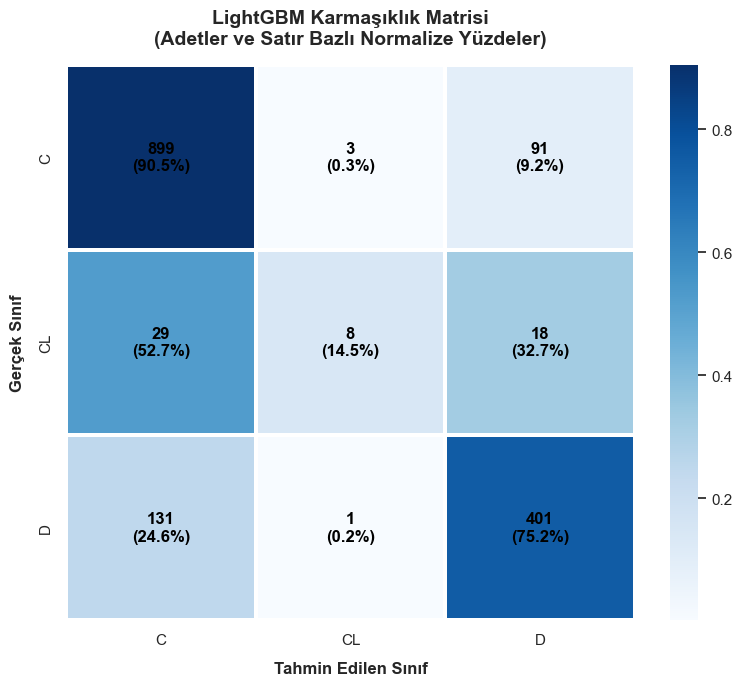

In [5]:
# Confusion matrix hesaplama
cm = confusion_matrix(y_test, y_pred)

# Satır bazında yüzde hesaplama (Recall yansıması)
cm_row_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Hücre etiketlerini oluşturma (Adet ve Satır Yüzdesi)
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_row_pct[i, j]*100:.1f}%)"

# Premium Isı Haritası Tasarımı
plt.figure(figsize=(8, 7))
sns.heatmap(
    cm_row_pct, 
    annot=annot, 
    fmt='', 
    cmap='Blues', 
    cbar=True,
    xticklabels=target_names, 
    yticklabels=target_names,
    linewidths=1.5,
    linecolor='white',
    annot_kws={"size": 12, "weight": "bold", "color": "black"}
)

# Eksen ve Başlık Etiketleri
plt.title('LightGBM Karmaşıklık Matrisi\n(Adetler ve Satır Bazlı Normalize Yüzdeler)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tahmin Edilen Sınıf', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Gerçek Sınıf', fontsize=12, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.savefig('../outputs/lgbm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Hata Analizi ve Türkçe Yorumlar

Karmaşıklık Matrisi ve Sınıflandırma Raporu incelendiğinde modelin tahmin davranışları ve yaptığı hatalar şu şekildedir:

### Sınıf Dağılımının Performansa Etkisi:
Veri setinde sınıflar oldukça dengesizdir. Test setinde:
- **C** (Yaşıyor) sınıfı: **993** hasta
- **D** (Vefat) sınıfı: **533** hasta
- **CL** (Nakil Sonrası Yaşıyor) sınıfı: Sadece **55** hasta (tüm test setinin yaklaşık %5'i)

Bu dengesizlik, modelin genel performansını ve sınıflara yaklaşımını doğrudan etkilemiştir.

---

### **CL (Nakil Sonrası Yaşıyor) Sınıfı Analizi (Detaylı İnceleme):**
- **Hassasiyet (Precision): 0.67**
  - **Yorum:** Modelin `CL` olarak tahmin ettiği hastaların yalnızca **%66.7**'i gerçekten `CL` sınıfına aittir. Geri kalan **%33.3**'lik kesim aslında `C` veya `D` sınıfındadır. Düşük precision değeri, modelin `CL` sınıfını tahmin ederken yüksek oranda yanlış alarm (False Positive) verdiğini göstermektedir.
- **Duyarlılık (Recall): 0.15**
  - **Yorum:** Gerçekte `CL` olan hastaların yalnızca **%14.5**'i model tarafından doğru tespit edilebilmiştir. Geri kalan **%85.5**'lik hasta grubu (`CL` hastaları), model tarafından çoğunlukla `C` (Yaşıyor) veya `D` (Vefat) olarak yanlış sınıflandırılmıştır. Bu durum, modelin `CL` sınıfını yakalamada ciddi bir yetersizlik (False Negative) yaşadığını kanıtlar.
- **F1 Score: 0.24**
  - **Yorum:** Precision ve Recall değerlerinin harmonik ortalaması olan F1 skoru **0.24** ile oldukça düşüktür. Bu değer, modelin bu azınlık sınıfı üzerinde dengeli ve güvenilir bir tahmin yapamadığını net bir şekilde ortaya koymaktadır.

---

### Hata Eğilimleri (Hangi Sınıflar Karışıyor?):
1. **CL Sınıfının Karışması:**
   - Gerçekte `CL` olan hastaların **%52.7**'si model tarafından `C` (Yaşıyor) olarak tahmin edilmiştir. Bu klinik açıdan en büyük hatadır; çünkü nakil geçirmiş ve kritik takip gerektiren bir hasta, normal yaşayan (`C`) stabil bir hasta ile karıştırılmaktadır.
   - Gerçekte `CL` olan hastaların **%32.7**'si ise `D` (Vefat) olarak sınıflandırılmıştır.
2. **C ve D Sınıflarının Karışması:**
   - En büyük hasta grubuna sahip olan **C (Yaşıyor)** sınıfı, **%90.5** recall oranıyla en iyi tahmin edilen sınıftır. Ancak gerçekte `C` olan hastaların **%9.2**'si vefat (`D`) olarak yanlış tahmin edilmiştir.
   - Gerçekte vefat etmiş olan **D (Vefat)** sınıfı hastalarının **%75.2**'si doğru yakalanırken, **%24.6**'si ise yaşıyor (`C`) olarak yanlış sınıflandırılmıştır.

### Klinik ve Model Geliştirme Önerileri (Sonraki Aşamalar İçin):
Modelin `CL` sınıfını doğru tahmin edememesi, klinik karar destek sistemlerinde riskli durumlar oluşturabilir. Bir sonraki aşamada model performansını artırmak amacıyla şu yöntemlerin uygulanması kritik önem taşımaktadır:
1. **Sınıf Ağırlıklandırması (Class Weights):** LightGBM modelinde `class_weight='balanced'` parametresi kullanılarak azınlık sınıfı olan `CL`'ye daha yüksek ceza puanı verilmesi sağlanabilir.
2. **Yeniden Örnekleme (Resampling):** Eğitim aşamasında `SMOTE` (sentetik veri üretimi) veya `RandomUnderSampler` gibi tekniklerle eğitim veri setinin dengelenmesi denenebilir.
3. **Eşik Değeri Ayarlaması (Threshold Tuning):** Sınıf olasılık eşiklerinin standart 0.50 yerine hassas şekilde optimize edilmesi düşünülebilir.
